# Investigation: Paneth -> Epithelial rule (Multi-Stage Evaluation)

This notebook investigates the association rule **Paneth -> Epithelial** across different disease stages (Control, Mild, Severe). It calculates per-FOV metrics to directly compare standard FP-Growth (binary) vs Weighted FP-Growth (distance-decay) pass rates.

**What it represents:** Paneth proximity to epithelium in the crypt base (duodenum-focused).
**Expected pattern:** Baseline in controls, decreases with disease as Paneth cells are lost; minimal in colon.

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Add root to path for utils
sys.path.append(os.path.abspath('../../../'))
from utils.rules import build_cell_item_token, passes_rule_support_policy, _extract_base_lineage

# --- Notebook config (no constants.py) ---
USE_FUNCTIONAL_MARKERS = True
CELLTYPE_MARKER_THRESHOLDS = {
    'Epithelial': {'Ki67': 2.5, 'HLADRDPDQ': 1.75},
    'CD8T': {'Ki67': 2.5, 'CD103': 2.0, 'CD69': 2.0, 'GZMB': 2.5},
    'CD4T': {'Ki67': 1.0, 'CD103': 1.0, 'CD69': 2.0, 'GZMB': 0.5},
    'Neutrophil': {'CD103': 2.75},
    'Neutrophil_CD15': {'CD103': 2.75}
}
CONFIG = {
    'RADIUS': 25.0,
    'BANDWIDTH': 15.0,
    'MIN_SUPPORT': 0.01,
    'MIN_ABS_SUPPORT': 5,
    'MIN_CONFIDENCE': 0.3,
    'MIN_LIFT': 1.2,
    'MIN_CELLS_PER_PATCH': 2,
    'HIGH_CONFIDENCE_THRESHOLD': 0.9,
    'HIGH_CONF_MIN_SUPPORT': 0.005,
}

RADIUS = CONFIG['RADIUS']
BANDWIDTH = CONFIG.get('BANDWIDTH', RADIUS)
MIN_SUPPORT = CONFIG['MIN_SUPPORT']
MIN_ABS_SUPPORT = CONFIG.get('MIN_ABS_SUPPORT', 5)
MIN_CONFIDENCE = CONFIG['MIN_CONFIDENCE']
MIN_LIFT = CONFIG['MIN_LIFT']
STAGE_COLUMN = "Pathological score"
STAGE_FOV_METRICS = []
SCORE_COLUMN = 'Clinical score'  # change to 'Clinical score' if needed

ANTECEDENT_REQUIRED_MARKERS = ()
CONSEQUENT_REQUIRED_MARKERS = ()

ANTECEDENT_BASE = 'Paneth'
CONSEQUENT_BASE = 'Epithelial'


## Step 1: Data Loading & Functional Subtypes

Load the cell and metadata tables, identify disease stages, and append the `functional_subtypes` array to every cell.

In [2]:
def _add_functional_subtypes(df):
    if not USE_FUNCTIONAL_MARKERS:
        df["functional_subtypes"] = [[] for _ in range(len(df))]
        return df
    functional_subtypes_list = [[] for _ in range(len(df))]
    idx_to_pos = {idx: i for i, idx in enumerate(df.index)}
    for base_type, markers in CELLTYPE_MARKER_THRESHOLDS.items():
        type_mask = df["cell type"] == base_type
        for marker, threshold in markers.items():
            if marker in df.columns:
                mask = type_mask & (df[marker] > threshold)
                subtype_label = f"{base_type}_{marker}+"
                matching_indices = df.index[mask]
                for idx in matching_indices:
                    functional_subtypes_list[idx_to_pos[idx]].append(subtype_label)
    df["functional_subtypes"] = functional_subtypes_list
    return df

cell_table_path = '../../../data/MIBIGutCsv/cell_table.csv'
fov_meta_path = '../../../data/MIBIGutCsv/fovs_metadata.csv'
biopsy_meta_path = '../../../data/MIBIGutCsv/biopsy_metadata.csv'

df_cells = pd.read_csv(cell_table_path)
df_fovs = pd.read_csv(fov_meta_path)
df_biopsy = pd.read_csv(biopsy_meta_path)

# Merge FOV with Biopsy to get score columns and Localization
df_fovs = pd.merge(
    df_fovs,
    df_biopsy[['Biopsy_ID', 'Pathological score', 'Clinical score', 'Localization']],
    left_on='Patient',
    right_on='Biopsy_ID',
    how='left'
)

# --- Standardized Organ Enrichment (from investigation_01_colon.ipynb) ---
def get_organ(row):
    if pd.notna(row.get("Localization")): return row["Localization"]
    cohort = str(row.get("Cohort", ""))
    if "Colon" in cohort: return "Colon"
    if "Duodenum" in cohort: return "Duodenum"
    return "Unknown"

df_fovs["Organ"] = df_fovs.apply(get_organ, axis=1)
# -------------------------------------------------------------------------

# Define FOV lists for each cohort, explicitly split by Stage and Organ
control_cohorts = ['Duodenum_Cohort_Control_1', 'Duodenum_Cohort_Control_2', 'Colon_Cohort_Control']

# Colon
colon_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_mild_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Mild') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()
colon_severe_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Severe') & (df_fovs['Organ'] == 'Colon')]['FOV'].tolist()

# Duodenum
duodenum_control_fovs = df_fovs[(df_fovs['Cohort'].isin(control_cohorts)) & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_mild_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Mild') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()
duodenum_severe_fovs = df_fovs[(df_fovs[SCORE_COLUMN] == 'Severe') & (df_fovs['Organ'] == 'Duodenum')]['FOV'].tolist()

# Normalize Coordinates
fov_to_size = df_fovs.set_index('FOV')['Size [um]'].to_dict()
def normalize_coords(row):
    size = fov_to_size.get(row['fov'], 800)
    res = 1024 if size == 400 else 2048
    return row['centroid_x'] * (size / res), row['centroid_y'] * (size / res)

df_cells[['x_um', 'y_um']] = df_cells.apply(lambda row: pd.Series(normalize_coords(row)), axis=1)

# Add Functional Subtypes
df_cells = _add_functional_subtypes(df_cells)

print(f"Total Cells: {len(df_cells)}")
print(f"Colon Control FOVs: {len(colon_control_fovs)}")
print(f"Colon Mild FOVs: {len(colon_mild_fovs)}")
print(f"Colon Severe FOVs: {len(colon_severe_fovs)}")
print(f"Duodenum Control FOVs: {len(duodenum_control_fovs)}")
print(f"Duodenum Mild FOVs: {len(duodenum_mild_fovs)}")
print(f"Duodenum Severe FOVs: {len(duodenum_severe_fovs)}")
print(f"Stage column used: {SCORE_COLUMN}")



Total Cells: 713372
Colon Control FOVs: 25
Colon Mild FOVs: 18
Colon Severe FOVs: 54
Duodenum Control FOVs: 52
Duodenum Mild FOVs: 98
Duodenum Severe FOVs: 41
Stage column used: Clinical score


## Step 2: Evaluation Framework

Define a reusable function that iterates over a given list of FOVs, computes both binary and weighted metrics *per FOV*, and verifies how many FOVs pass the algorithm thresholds. Finally, it visualizes the FOV with the highest target cell density.

In [3]:
def evaluate_cohort(cohort_name, fov_list, df_cells_all):
    print(f"==============================================")
    print(f"Evaluating Cohort: {cohort_name}")
    print(f"==============================================\n")

    valid_fovs = 0
    stage_binary_transactions = []
    stage_weighted_transactions = []

    max_target_count = -1
    max_target_fov = None
    organ = None
    stage = cohort_name
    if " - " in cohort_name:
        organ, stage = [part.strip() for part in cohort_name.split(" - ", 1)]

    def _parse_token(token, suffix):
        token = str(token)
        tail = f"_{suffix}"
        if not token.endswith(tail):
            return None, set()
        core = token[:-len(tail)]
        base = _extract_base_lineage(core)
        markers = {part for part in core.split('_') if part.endswith('+')}
        return base, markers

    def _matches_rule_item(token, base, suffix, required_markers=()):
        token_base, token_markers = _parse_token(token, suffix)
        if token_base != base:
            return False
        return set(required_markers).issubset(token_markers)

    def _has_item(binary_trans, base, suffix, required_markers=()):
        return any(_matches_rule_item(item, base, suffix, required_markers) for item in binary_trans)

    def _weight_for_item(weighted_trans, base, suffix, required_markers=()):
        return min(
            sum(float(v) for k, v in weighted_trans.items() if _matches_rule_item(k, base, suffix, required_markers)),
            1.0,
        )

    def _conviction(confidence, support_con):
        if confidence >= 1:
            return float("inf")
        denom = 1 - confidence
        if denom <= 0:
            return float("inf")
        return (1 - support_con) / denom

    def _rule_item_label(base, required_markers):
        if not required_markers:
            return base
        return f"{base}_{'_'.join(required_markers)}"

    for fov in fov_list:
        fov_data = df_cells_all[df_cells_all['fov'] == fov]
        if fov_data.empty:
            continue
        valid_fovs += 1

        coords = fov_data[['x_um', 'y_um']].values
        types = fov_data['cell type'].values
        subtypes = fov_data['functional_subtypes'].values

        target_count = sum(
            1
            for t, st in zip(types, subtypes)
            if _matches_rule_item(
                build_cell_item_token(t, st, suffix='CENTER'),
                ANTECEDENT_BASE,
                'CENTER',
                ANTECEDENT_REQUIRED_MARKERS,
            )
        )
        if target_count > max_target_count:
            max_target_count = target_count
            max_target_fov = fov

        nn = NearestNeighbors(radius=RADIUS).fit(coords)
        distances, neighbors_idx = nn.radius_neighbors(coords, return_distance=True)

        fov_binary_trans = []
        fov_weighted_trans = []

        for i, (idxs, dists) in enumerate(zip(neighbors_idx, distances)):
            if len(idxs) < CONFIG.get("MIN_CELLS_PER_PATCH", 2):
                continue

            center_token = build_cell_item_token(types[i], subtypes[i], suffix='CENTER')

            b_trans = {center_token}
            w_trans = {center_token: 1.0}

            for n_idx, d in zip(idxs, dists):
                if n_idx == i:
                    continue

                neighbor_token = build_cell_item_token(types[n_idx], subtypes[n_idx], suffix='NEIGHBOR')
                b_trans.add(neighbor_token)

                w = np.exp(-0.5 * (d / BANDWIDTH) ** 2)
                w_trans[neighbor_token] = w_trans.get(neighbor_token, 0.0) + w

            w_trans = {k: min(v, 1.0) for k, v in w_trans.items()}

            fov_binary_trans.append(b_trans)
            fov_weighted_trans.append(w_trans)

        if not fov_binary_trans:
            continue

        stage_binary_transactions.extend(fov_binary_trans)
        stage_weighted_transactions.extend(fov_weighted_trans)

    if not stage_binary_transactions:
        print(f"No transactions found for {cohort_name}.")
        return pd.DataFrame()

    n_trans = len(stage_binary_transactions)
    b_sup_ant = sum(
        1 for t in stage_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
    ) / n_trans
    b_sup_con = sum(
        1 for t in stage_binary_transactions
        if _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / n_trans
    b_sup_joint = sum(
        1 for t in stage_binary_transactions
        if _has_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        and _has_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
    ) / n_trans
    b_conf = b_sup_joint / b_sup_ant if b_sup_ant > 0 else 0
    b_lift = b_conf / b_sup_con if b_sup_con > 0 else 0
    b_leverage = b_sup_joint - (b_sup_ant * b_sup_con)
    b_conviction = _conviction(b_conf, b_sup_con)
    b_pass = b_sup_joint >= MIN_SUPPORT and b_conf >= MIN_CONFIDENCE and b_lift >= MIN_LIFT

    w_sup_ant = sum(
        _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS)
        for t in stage_weighted_transactions
    ) / n_trans
    w_sup_con = sum(
        _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS)
        for t in stage_weighted_transactions
    ) / n_trans
    w_sup_joint = sum(
        min(
            _weight_for_item(t, ANTECEDENT_BASE, 'CENTER', ANTECEDENT_REQUIRED_MARKERS),
            _weight_for_item(t, CONSEQUENT_BASE, 'NEIGHBOR', CONSEQUENT_REQUIRED_MARKERS),
        )
        for t in stage_weighted_transactions
    ) / n_trans
    w_conf = w_sup_joint / w_sup_ant if w_sup_ant > 0 else 0
    w_lift = w_conf / w_sup_con if w_sup_con > 0 else 0
    w_leverage = w_sup_joint - (w_sup_ant * w_sup_con)
    w_conviction = _conviction(w_conf, w_sup_con)
    w_pass = (
        passes_rule_support_policy(CONFIG, w_sup_joint, w_sup_ant, w_sup_con, w_conf, w_lift, num_transactions=n_trans)
        and w_conf >= MIN_CONFIDENCE
        and w_lift >= MIN_LIFT
    )

    ant_label = _rule_item_label(ANTECEDENT_BASE, ANTECEDENT_REQUIRED_MARKERS)
    con_label = _rule_item_label(CONSEQUENT_BASE, CONSEQUENT_REQUIRED_MARKERS)
    print(f"\n[Stage-Mixed Metrics: {ant_label}_CENTER -> {con_label}_NEIGHBOR]")
    print(f"FOVs pooled: {valid_fovs} | Transactions: {n_trans}")
    print(f"  [Binary]   Sup: {b_sup_joint:.4f} | Conf: {b_conf:.4f} | Lift: {b_lift:.4f} | Pass: {b_pass}")
    print(f"  [Weighted] Sup: {w_sup_joint:.4f} | Conf: {w_conf:.4f} | Lift: {w_lift:.4f} | Pass: {w_pass}\n")

    if max_target_fov:
        print(f"\nVisualizing Representative FOV: {max_target_fov} ({max_target_count} matching antecedent cells)")
        _plot_fov(max_target_fov, df_cells_all)

    stage_metrics = {
        "Cohort": cohort_name,
        "Organ": organ,
        "Stage": stage,
        "N_FOVS": valid_fovs,
        "N_Transactions": n_trans,
        "Binary_support": b_sup_joint,
        "Binary_confidence": b_conf,
        "Binary_lift": b_lift,
        "Binary_conviction": b_conviction,
        "Binary_leverage": b_leverage,
        "Binary_pass": b_pass,
        "Weighted_support": w_sup_joint,
        "Weighted_confidence": w_conf,
        "Weighted_lift": w_lift,
        "Weighted_conviction": w_conviction,
        "Weighted_leverage": w_leverage,
        "Weighted_pass": w_pass,
    }
    return pd.DataFrame([stage_metrics])

def _plot_fov(fov, df_cells_all):
    fov_df = df_cells_all[df_cells_all['fov'] == fov].copy()

    def get_plot_class(row):
        if row['cell type'] == 'Paneth': return 'Paneth'
        elif row['cell type'] == 'Epithelial': return 'Epithelial'
        return 'Other'
        
    fov_df['PlotClass'] = fov_df.apply(get_plot_class, axis=1)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 10))
    others = fov_df[fov_df['PlotClass'] == 'Other']
    sns.scatterplot(data=others, x='x_um', y='y_um', color='lightgrey', alpha=0.3, s=20)
    epi = fov_df[fov_df['PlotClass'] == 'Epithelial']
    sns.scatterplot(data=epi, x='x_um', y='y_um', color='blue', alpha=0.5, s=30, label='Epithelial')
    target = fov_df[fov_df['PlotClass'] == 'Paneth']
    sns.scatterplot(data=target, x='x_um', y='y_um', color='red', s=70, edgecolor='black', zorder=10, label='Paneth')

    plt.title(f"Spatial Distribution in FOV {fov}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.show()


## Stage-Mixed Metric Summary

Run after each organ's Severe cohort to summarize stage-mixed metrics.

In [4]:
def plot_stage_metric_summary(stage_metrics, organ=None, stage_column="Pathological score"):
    if not stage_metrics:
        print('No stage-mixed metrics collected yet. Run the cohort evaluations first.')
        return
    if isinstance(stage_metrics, list):
        plot_df = pd.concat(stage_metrics, ignore_index=True)
    else:
        plot_df = stage_metrics.copy()

    if organ:
        plot_df = plot_df[plot_df['Organ'] == organ].copy()
    if plot_df.empty:
        print(f"No stage-mixed metrics found for {organ or 'all organs'}.")
        return

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    stage_order = ['Control', 'Mild', 'Severe']
    available_stages = [s for s in stage_order if s in plot_df['Stage'].dropna().unique()]
    if available_stages:
        plot_df['Stage'] = pd.Categorical(plot_df['Stage'], categories=available_stages, ordered=True)
        stage_levels = list(plot_df['Stage'].cat.categories)
    else:
        stage_levels = sorted(plot_df['Stage'].dropna().unique())

    stage_counts = plot_df.drop_duplicates('Stage').set_index('Stage')['N_FOVS'].to_dict()
    stage_labels = [f"{stage} (n={stage_counts.get(stage, 0)})" for stage in stage_levels]

    metric_defs = [
        ('support', 'Support'),
        ('confidence', 'Confidence'),
        ('lift', 'Lift'),
        ('conviction', 'Conviction'),
        ('leverage', 'Leverage'),
    ]

    palette = sns.color_palette("Set2", n_colors=len(stage_levels))
    title_organ = organ or "All organs"
    for mode in ['Binary', 'Weighted']:
        fig, axes = plt.subplots(1, len(metric_defs), figsize=(4 * len(metric_defs), 4), sharey=False)
        for ax, (key, label) in zip(axes, metric_defs):
            col = f"{mode}_{key}"
            if col not in plot_df.columns:
                ax.axis('off')
                continue
            sns.barplot(
                data=plot_df,
                x='Stage',
                y=col,
                order=stage_levels,
                palette=palette,
                ax=ax,
                errorbar=None,
            )
            sns.stripplot(
                data=plot_df,
                x='Stage',
                y=col,
                order=stage_levels,
                color='black',
                alpha=0.7,
                size=4,
                jitter=0.12,
                ax=ax,
            )
            ax.set_title(f"{mode} {label}")
            ax.set_xlabel(stage_column)
            ax.set_ylabel(label)
            ax.set_xticklabels(stage_labels, rotation=0)
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        fig.suptitle(f"{mode} stage-mixed metrics ({title_organ} | {stage_column})", y=1.08, fontsize=12)
        plt.tight_layout()
        plt.subplots_adjust(top=0.82)
        plt.show()


## Step 3: Run Evaluation on Control Cohort

Evaluating Cohort: Colon - Control


[Stage-Mixed Metrics: Paneth_CENTER -> Epithelial_NEIGHBOR]
FOVs pooled: 25 | Transactions: 81753
  [Binary]   Sup: 0.0001 | Conf: 1.0000 | Lift: 1.7527 | Pass: False
  [Weighted] Sup: 0.0001 | Conf: 1.0000 | Lift: 1.9670 | Pass: False


Visualizing Representative FOV: Control_Colon_02_FOV_6 (5 matching antecedent cells)


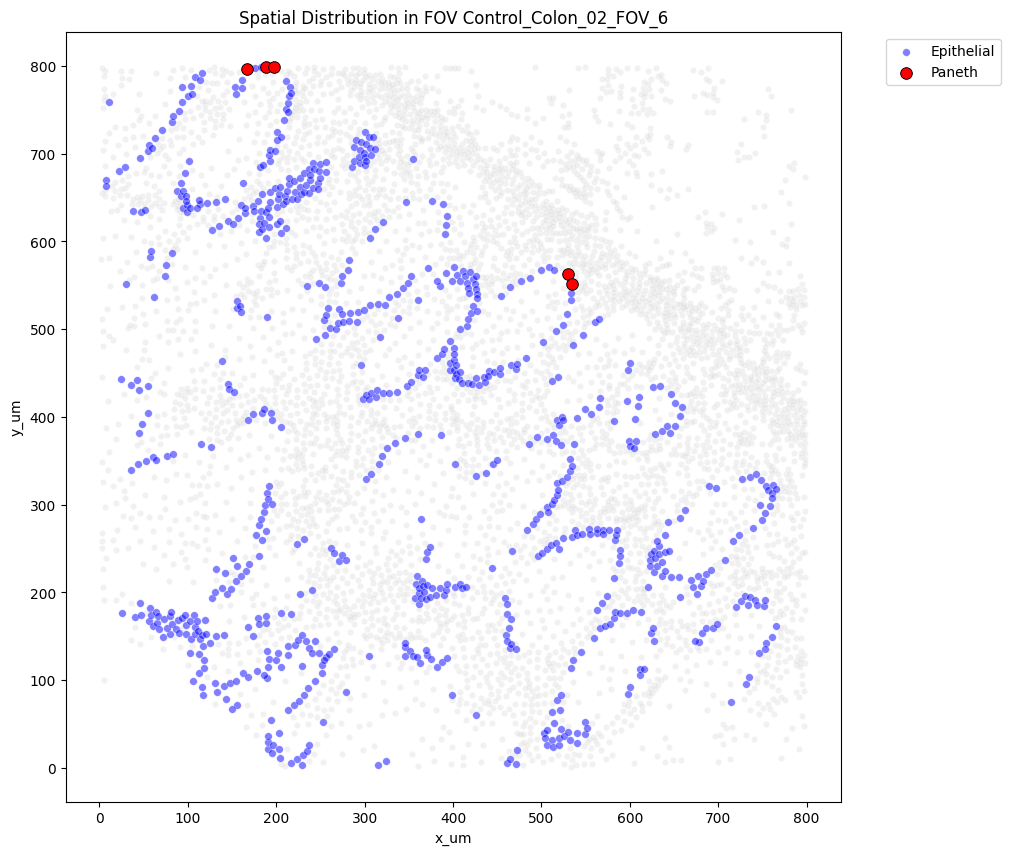

In [5]:
metrics = evaluate_cohort("Colon - Control", colon_control_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Colon - Mild


[Stage-Mixed Metrics: Paneth_CENTER -> Epithelial_NEIGHBOR]
FOVs pooled: 18 | Transactions: 32371
  [Binary]   Sup: 0.0002 | Conf: 1.0000 | Lift: 1.3506 | Pass: False
  [Weighted] Sup: 0.0002 | Conf: 1.0000 | Lift: 1.4592 | Pass: False


Visualizing Representative FOV: GVHD_23_FOV_1 (7 matching antecedent cells)


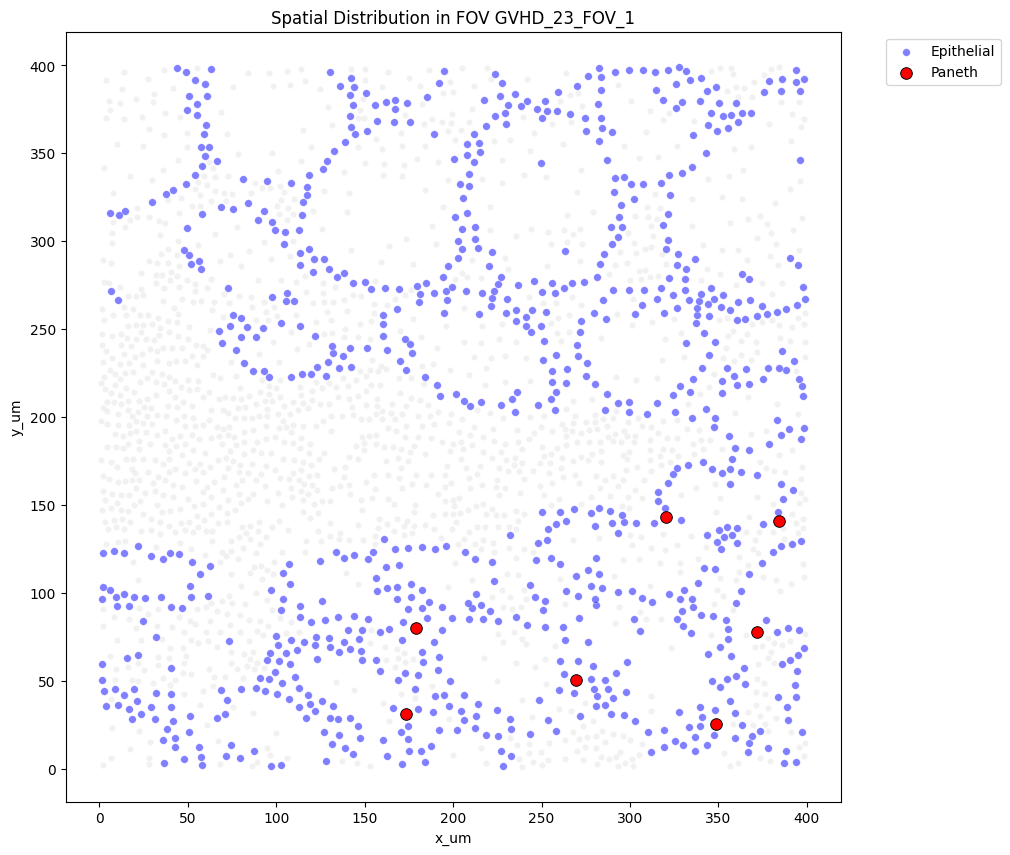

In [6]:
metrics = evaluate_cohort("Colon - Mild", colon_mild_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Colon - Severe


[Stage-Mixed Metrics: Paneth_CENTER -> Epithelial_NEIGHBOR]
FOVs pooled: 54 | Transactions: 109927
  [Binary]   Sup: 0.0002 | Conf: 1.0000 | Lift: 1.4991 | Pass: False
  [Weighted] Sup: 0.0002 | Conf: 1.0000 | Lift: 1.6075 | Pass: False


Visualizing Representative FOV: GVHD_41_FOV_3 (3 matching antecedent cells)


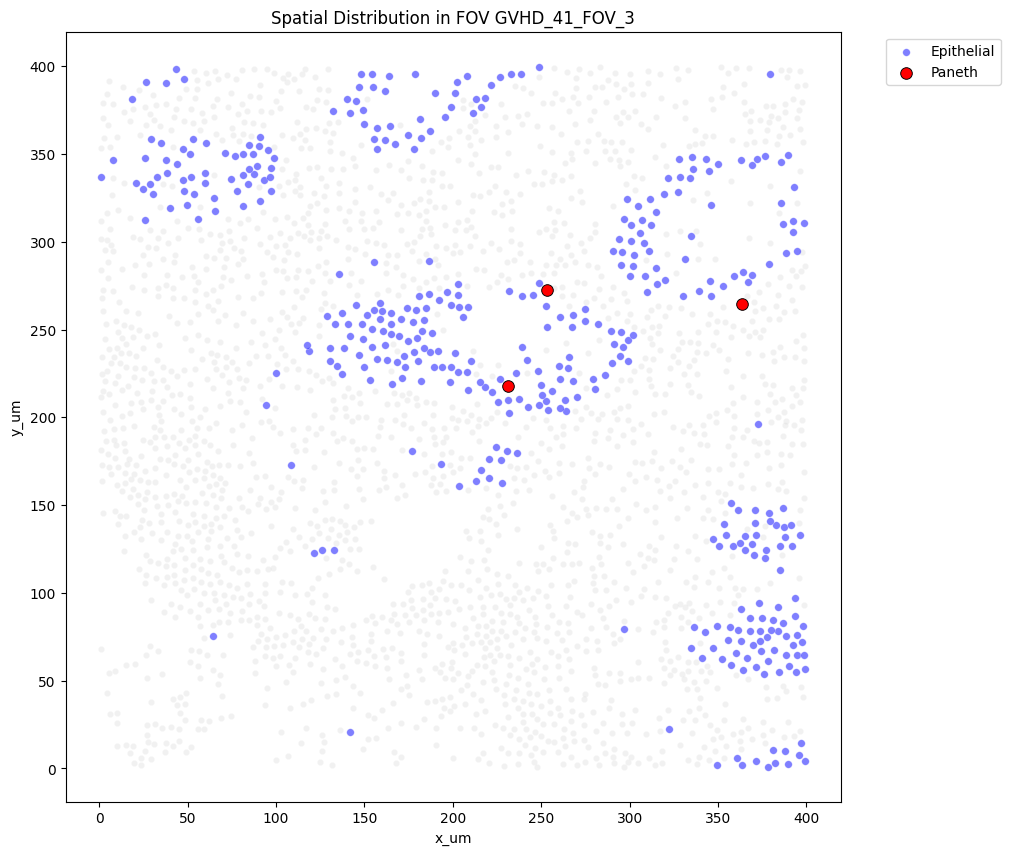

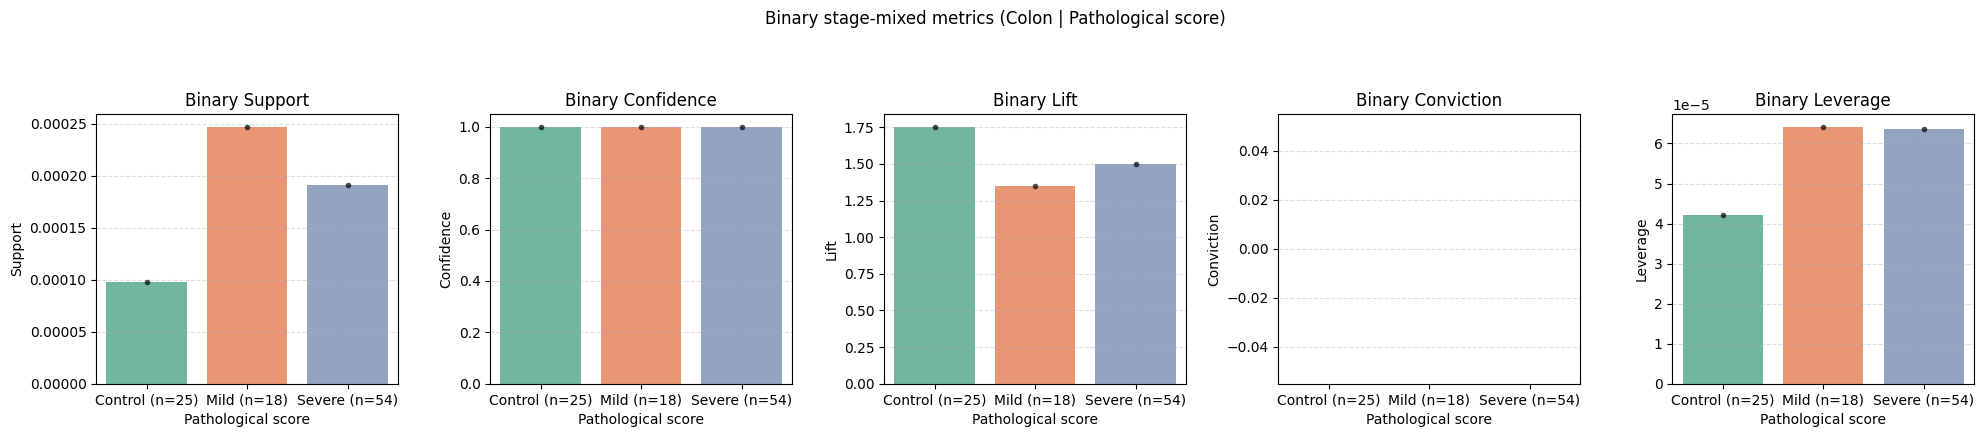

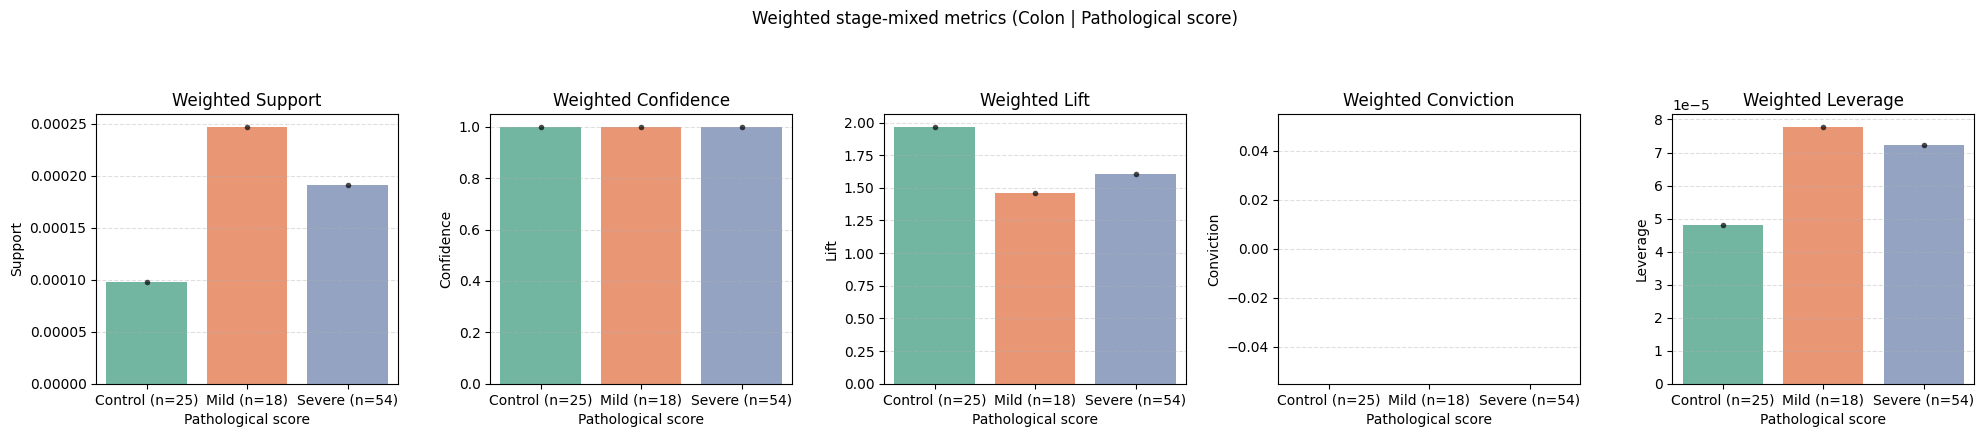

In [7]:
metrics = evaluate_cohort("Colon - Severe", colon_severe_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)
plot_stage_metric_summary(STAGE_FOV_METRICS, organ="Colon", stage_column=STAGE_COLUMN)


Evaluating Cohort: Duodenum - Control


[Stage-Mixed Metrics: Paneth_CENTER -> Epithelial_NEIGHBOR]
FOVs pooled: 52 | Transactions: 178181
  [Binary]   Sup: 0.0048 | Conf: 0.9885 | Lift: 1.2824 | Pass: False
  [Weighted] Sup: 0.0047 | Conf: 0.9754 | Lift: 1.3366 | Pass: False


Visualizing Representative FOV: Control_08_FOV_1 (81 matching antecedent cells)


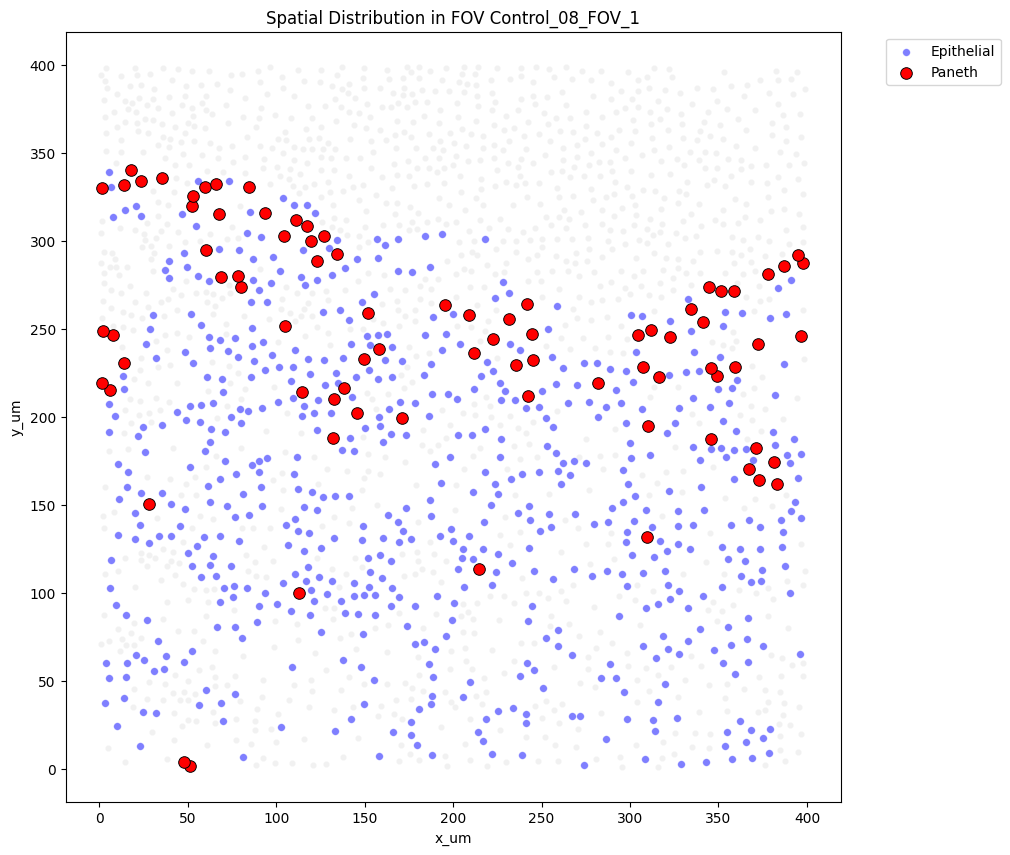

In [8]:
metrics = evaluate_cohort("Duodenum - Control", duodenum_control_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Duodenum - Mild


[Stage-Mixed Metrics: Paneth_CENTER -> Epithelial_NEIGHBOR]
FOVs pooled: 98 | Transactions: 219165
  [Binary]   Sup: 0.0158 | Conf: 0.8679 | Lift: 1.2685 | Pass: True
  [Weighted] Sup: 0.0153 | Conf: 0.8409 | Lift: 1.3015 | Pass: True


Visualizing Representative FOV: GVHD_05_FOV_2_R (375 matching antecedent cells)


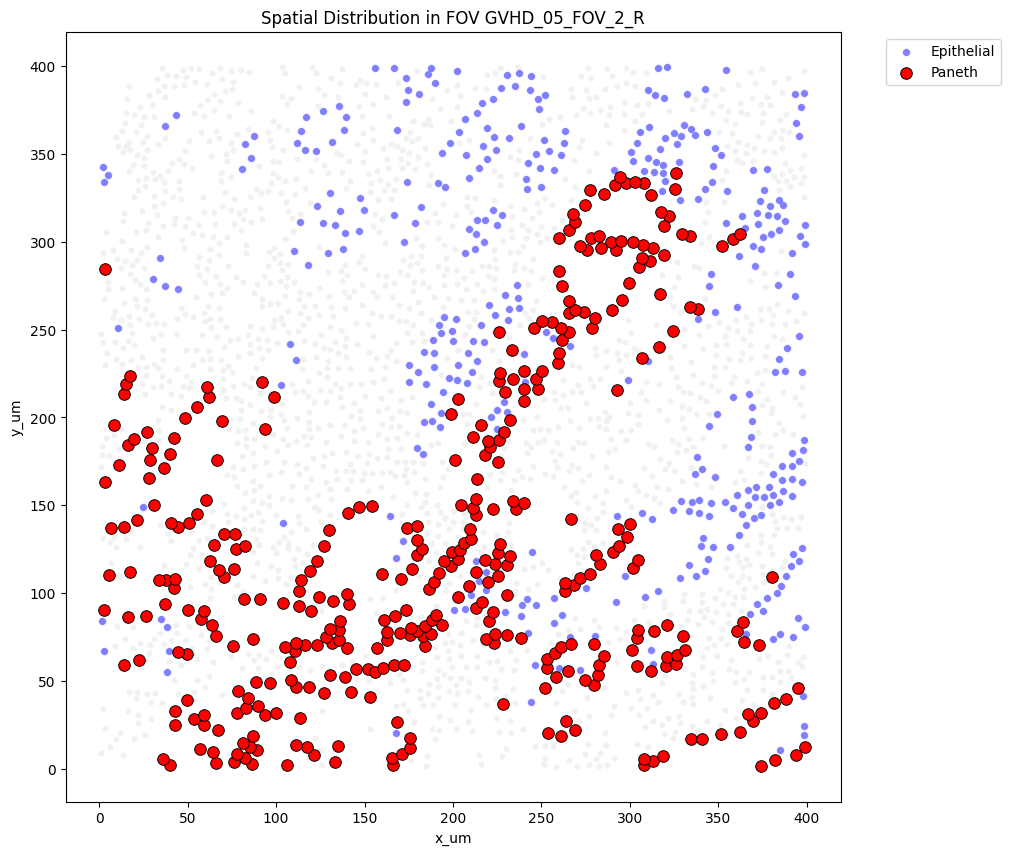

In [9]:
metrics = evaluate_cohort("Duodenum - Mild", duodenum_mild_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)


Evaluating Cohort: Duodenum - Severe


[Stage-Mixed Metrics: Paneth_CENTER -> Epithelial_NEIGHBOR]
FOVs pooled: 41 | Transactions: 91830
  [Binary]   Sup: 0.0075 | Conf: 0.9648 | Lift: 2.1280 | Pass: False
  [Weighted] Sup: 0.0073 | Conf: 0.9401 | Lift: 2.2374 | Pass: True


Visualizing Representative FOV: GVHD_19_FOV_2 (78 matching antecedent cells)


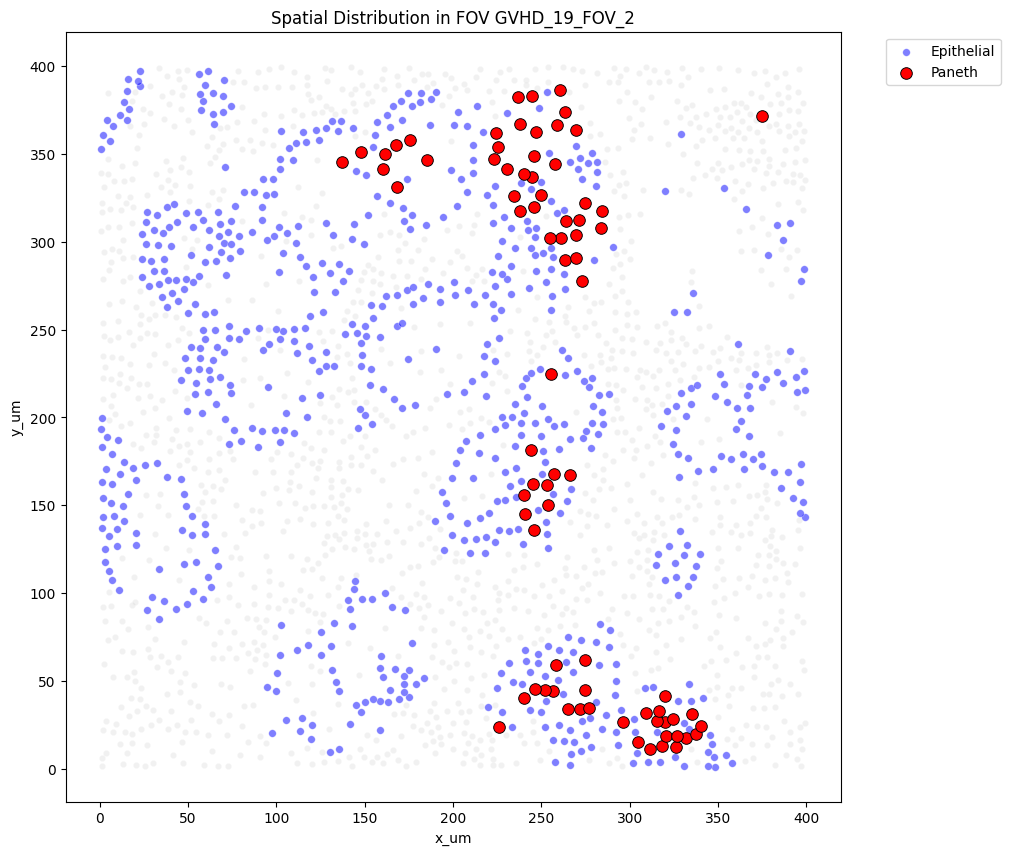

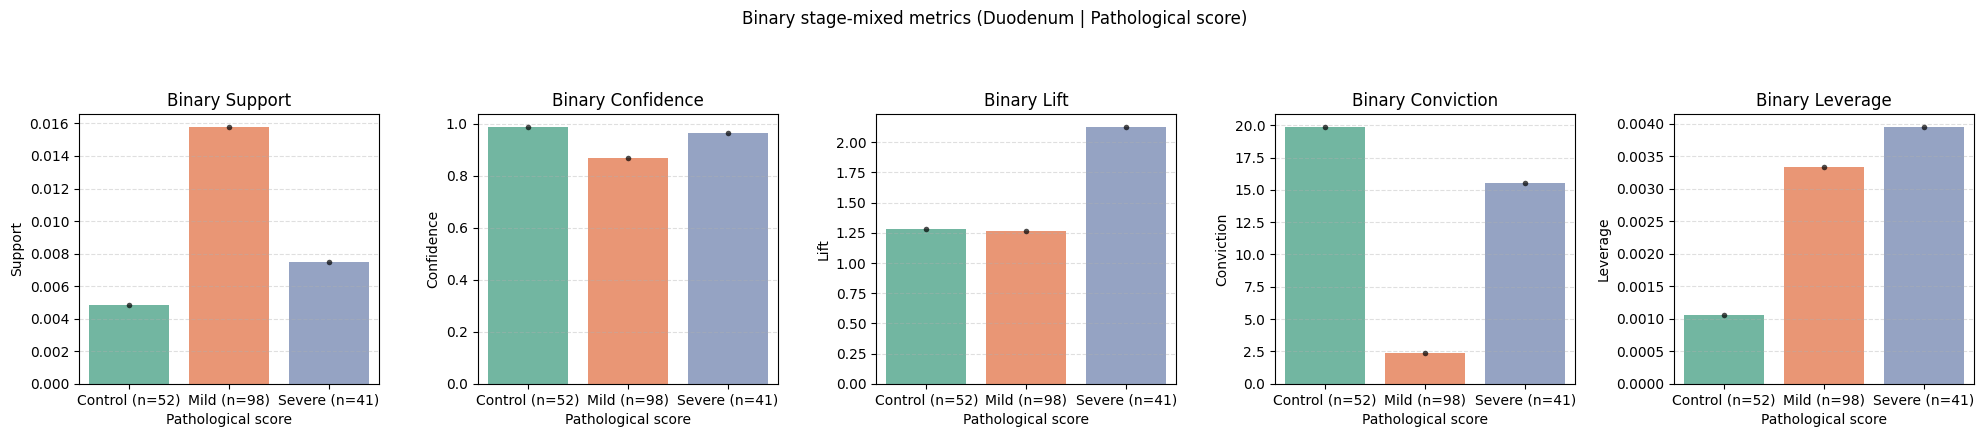

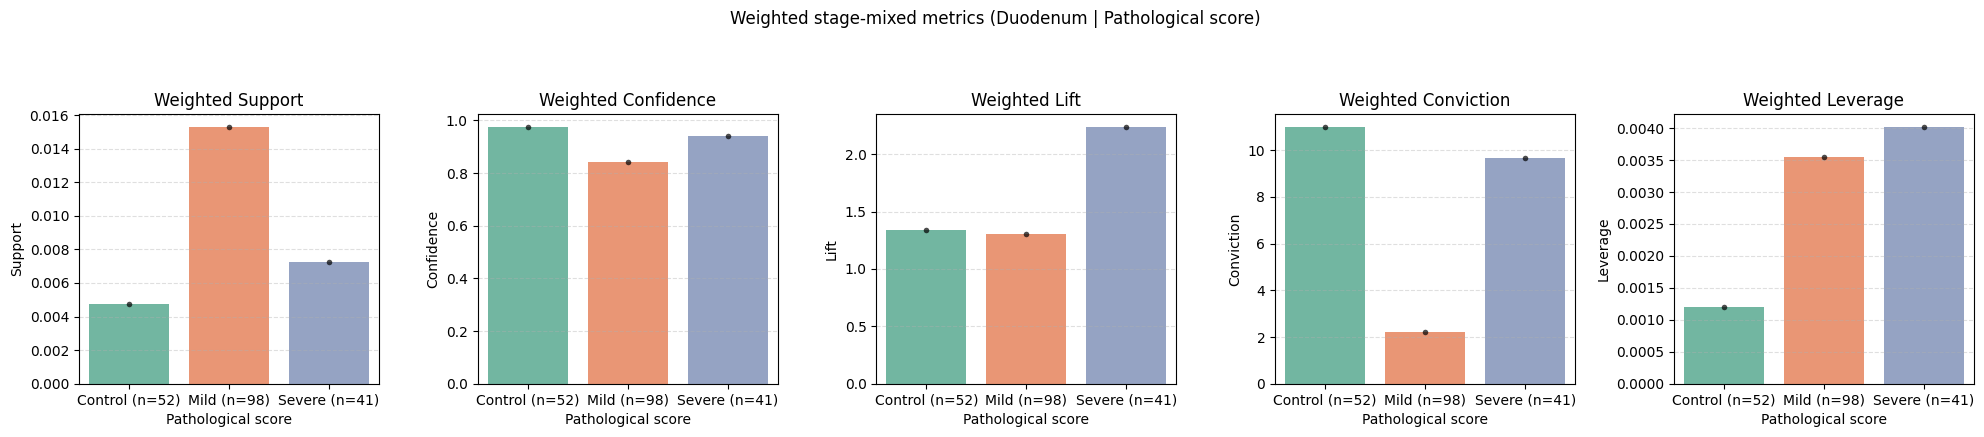

In [10]:
metrics = evaluate_cohort("Duodenum - Severe", duodenum_severe_fovs, df_cells)
if not metrics.empty:
    STAGE_FOV_METRICS.append(metrics)
plot_stage_metric_summary(STAGE_FOV_METRICS, organ="Duodenum", stage_column=STAGE_COLUMN)
